In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/advaithareddypatti/churn-data/Churn_Modelling.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/advaithareddypatti/churn-data/Churn_Modelling.csv")
print(df.head)

print(df["Exited"].value_counts())


<bound method NDFrame.head of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfPro

In [3]:
df["Gender"].value_counts()


Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [4]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)



In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [8]:
from sklearn.model_selection import train_test_split
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)
X=df.drop(columns=["Exited"])
y=df["Exited"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,False,False,True
1561,632,42,4,119624.60,2,1,1,195978.86,True,False,True
1670,559,24,3,114739.92,1,1,0,85891.02,False,True,True
6087,561,27,9,135637.00,1,1,0,153080.40,False,False,False
6669,517,56,9,142147.32,1,0,0,39488.04,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
5734,768,54,8,69712.74,1,1,1,69381.05,False,False,True
5191,682,58,1,0.00,1,1,1,706.50,False,False,False
5390,735,38,1,0.00,3,0,0,92220.12,False,False,False
860,667,43,8,190227.46,1,1,0,97508.04,False,False,True


In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)


In [ ]:
!pip uninstall -y jax jaxlib
!pip install --upgrade pip
!pip install tensorflow

In [10]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense



2026-04-03 13:40:26.849670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775223626.878933    1770 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775223626.886474    1770 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775223626.906888    1770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775223626.906923    1770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775223626.906926    1770 computation_placer.cc:177] computation placer alr

In [18]:
model=Sequential()
model.add(Dense(3,activation="sigmoid",input_dim=11))
model.add(Dense(2,activation="sigmoid",input_dim=3))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47 (188.00 B)

 Trainable params: 47 (188.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
from sklearn.metrics import accuracy_score

In [56]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])
history=model.fit(X_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8385 - loss: 0.3966 - val_accuracy: 0.8375 - val_loss: 0.3962
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8312 - loss: 0.4066 - val_accuracy: 0.8363 - val_loss: 0.3963
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8325 - loss: 0.4076 - val_accuracy: 0.8375 - val_loss: 0.3963
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8321 - loss: 0.4108 - val_accuracy: 0.8369 - val_loss: 0.3963
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8445 - loss: 0.3927 - val_accuracy: 0.8375 - val_loss: 0.3964
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8417 - loss: 0.3978 - val_accuracy: 0.8375 - val_loss: 0.3963
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.4028 - val_accuracy: 0.8363 - val_loss: 0.3963
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8393 - loss: 0.4013 - val_accu

In [28]:
model.layers[0].get_weights()

[array([[-0.20682853, -0.02445461,  0.12860033],
        [ 2.8352053 ,  0.36509007, -3.2528331 ],
        [ 0.18910633,  0.13391119,  0.23627007],
        [ 0.2247768 , -0.3592202 ,  0.4450513 ],
        [-0.08767174,  0.03805865,  0.21107668],
        [ 0.33808982,  0.16318378,  0.01676608],
        [ 0.77769   ,  1.7754321 , -1.4373521 ],
        [-0.3467964 , -0.14790411, -0.19230926],
        [ 0.25808257, -0.5811471 , -0.05837378],
        [ 0.15030453,  0.01025636,  0.02318156],
        [-0.20962754,  0.6252034 , -0.38330472]], dtype=float32),
 array([ 0.04938345, -0.27400964,  1.0352484 ], dtype=float32)]

In [29]:
model.layers[1].get_weights()

[array([[-2.0751479, -2.2018003],
        [ 3.6797504,  3.0112793],
        [ 1.0500172,  1.8487165]], dtype=float32),
 array([-0.7650354 , -0.32433766], dtype=float32)]

In [30]:
model.layers[2].get_weights()

[array([[-1.7853701],
        [-3.1391602]], dtype=float32),
 array([1.7267293], dtype=float32)]

In [31]:
X_test_scaled=scaler.fit_transform(X_test)
y_initial=model.predict(X_test_scaled)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [48]:
print(y_initial)
y_pred=np.where(y_initial<=0.5,0,1)
print("Actual predictions: ")
print(y_pred)

[[0.13382144]
 [0.116672  ]
 [0.4324642 ]
 ...
 [0.5556847 ]
 [0.07791955]
 [0.22664446]]
Actual predictions: 
[[0]
 [0]
 [0]
 ...
 [1]
 [0]
 [0]]


In [49]:
print(y_pred.shape)

(2000, 1)


In [51]:
acc_score=accuracy_score(y_test,y_pred)
print("Accuracy_score=",acc_score)


Accuracy_score= 0.836


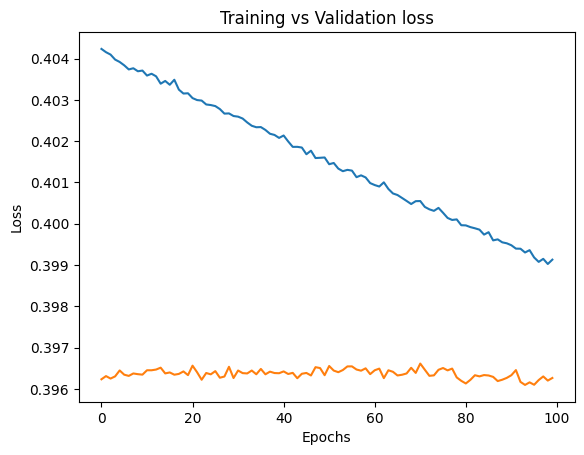

In [57]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label="Training_loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation loss")
plt.show()

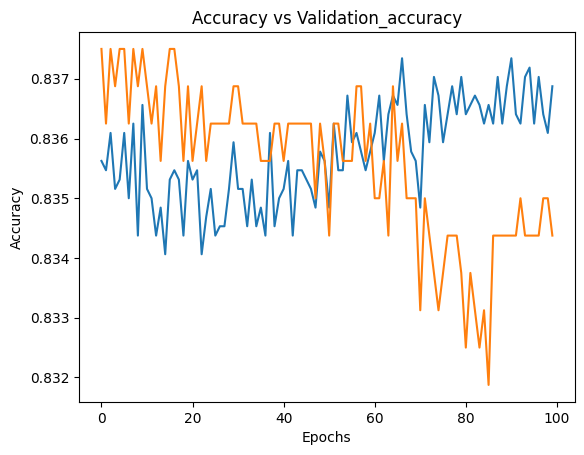

In [59]:
plt.figure()
plt.title("Accuracy vs Validation_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()
